# Fine-tuning BERT on PolitiFact

This notebook fine-tunes `bert-base-uncased` for binary fake-news classification on the PolitiFact dataset. It is designed to plug into the existing comparison (Naive Bayes, TF-IDF + Logistic Regression, BiLSTM) — the train/test split uses the same seed and stratification so the metrics are directly comparable.

In [1]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import evaluate

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device: Tesla T4


## Load the dataset

In [3]:
from google.colab import files
uploaded = files.upload()  # select politifact_factcheck_data.json

Saving politifact_factcheck_data.json to politifact_factcheck_data.json


In [22]:
df = pd.read_json("politifact_factcheck_data.json", lines=True)

label_map = {
    "true": "truth", "mostly-true": "truth", "half-true": "truth",
    "false": "fake", "mostly-false": "fake", "pants-fire": "fake",
}
df["label_text"] = df["verdict"].map(label_map)
# 1 = fake, 0 = truth. Encoding fake as the positive class keeps the metrics intuitive
# (precision/recall talk about catching fakes).
df["label"] = (df["label_text"] == "fake").astype(int)

print(df["label_text"].value_counts())
print(f"\nTotal: {len(df)} statements")

label_text
fake     11760
truth     9392
Name: count, dtype: int64

Total: 21152 statements


## Splits

`test_size=0.2`, `stratify`, `random_state=42`. A 10% slice of training data is held out as a validation set so the Trainer can pick the best checkpoint without touching the test set.

In [23]:
train_df, test_df = train_test_split(
    df[["statement", "label"]],
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED,
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=SEED,
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 15228 | Val: 1693 | Test: 4231


## Tokenization

PolitiFact statements are short, so a small `MAX_LEN` keeps training fast without losing content. The cell below checks the actual token-length distribution before committing to a value.

In [24]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_lens = [
    len(tokenizer.encode(s, add_special_tokens=True))
    for s in df["statement"].sample(2000, random_state=SEED)
]
print(f"median={np.median(sample_lens):.0f}  "
      f"p95={np.percentile(sample_lens, 95):.0f}  "
      f"p99={np.percentile(sample_lens, 99):.0f}  "
      f"max={max(sample_lens)}")

median=25  p95=45  p99=57  max=87


In [25]:
MAX_LEN = 128  # comfortably above p99 in the sample above

def tokenize(batch):
    return tokenizer(batch["statement"], truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(tokenize, batched=True)
val_ds   = Dataset.from_pandas(val_df,   preserve_index=False).map(tokenize, batched=True)
test_ds  = Dataset.from_pandas(test_df,  preserve_index=False).map(tokenize, batched=True)

Map:   0%|          | 0/15228 [00:00<?, ? examples/s]

Map:   0%|          | 0/1693 [00:00<?, ? examples/s]

Map:   0%|          | 0/4231 [00:00<?, ? examples/s]

## Model and metrics

Standard BERT classification head on top of `bert-base-uncased`. The `id2label` / `label2id` mappings make the saved model self-describing.

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "truth", 1: "fake"},
    label2id={"truth": 0, "fake": 1},
)

acc_metric = evaluate.load("accuracy")
f1_metric  = evaluate.load("f1")

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_fake":  f1_metric.compute(predictions=preds, references=labels, pos_label=1)["f1"],
    }

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [27]:
args = TrainingArguments(
    output_dir="bert-politifact",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Fake
1,0.580621,0.574843,0.685765,0.685733,0.682578
2,0.501810,0.582202,0.689900,0.687825,0.713271
3,0.422786,0.623989,0.686946,0.686922,0.689696


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1428, training_loss=0.5249184647194144, metrics={'train_runtime': 221.6557, 'train_samples_per_second': 206.103, 'train_steps_per_second': 6.442, 'total_flos': 1286064227493360.0, 'train_loss': 0.5249184647194144, 'epoch': 3.0})

## Test-set evaluation

In [28]:
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = np.array(test_ds["label"])

print(classification_report(y_true, y_pred, target_names=["truth", "fake"], digits=3))

              precision    recall  f1-score   support

       truth      0.640     0.680     0.660      1879
        fake      0.731     0.695     0.712      2352

    accuracy                          0.688      4231
   macro avg      0.686     0.687     0.686      4231
weighted avg      0.691     0.688     0.689      4231



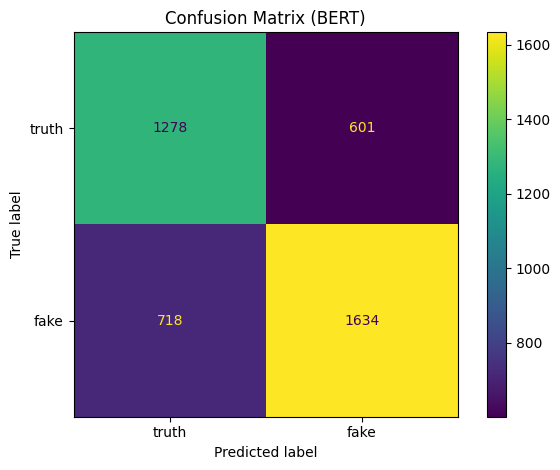

In [29]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["truth", "fake"]).plot(cmap="viridis")
plt.title("Confusion Matrix (BERT)")
plt.tight_layout()
plt.show()

## Save the model


In [30]:
trainer.save_model("bert-politifact-final")
tokenizer.save_pretrained("bert-politifact-final")
print("Saved to ./bert-politifact-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./bert-politifact-final


In [32]:
from huggingface_hub import notebook_login
notebook_login()

trainer.push_to_hub("riskilinardi/bert-politifact-fakenews")
tokenizer.push_to_hub("riskilinardi/bert-politifact-fakenews")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...itifact/model.safetensors:   0%|          | 14.2kB /  438MB            

  ...itifact/training_args.bin:   2%|1         |  80.0B / 5.20kB            

CommitInfo(commit_url='https://huggingface.co/riskilinardi/bert-politifact-fakenews/commit/2e57cc333f59b4599343d5a7ea02e99ca874a34e', commit_message='Upload tokenizer', commit_description='', oid='2e57cc333f59b4599343d5a7ea02e99ca874a34e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/riskilinardi/bert-politifact-fakenews', endpoint='https://huggingface.co', repo_type='model', repo_id='riskilinardi/bert-politifact-fakenews'), pr_revision=None, pr_num=None)